# Joint TESS and PFS Analysis of TOI-1233

Run the shared Miletos observational pipeline on Transiting Exoplanet Survey Satellite photometry and Planet Finder Spectrograph radial velocities. Miletos loads the repository data, configures the planetary model, performs the analysis, and writes the standard figures.

In [1]:
from tdpy.verbosity import print as narrate
from IPython.display import Image, display

from miletos.paths import get_repository_path
from miletos.toi1233 import run_toi1233_observation

## Select the Planetary Model

The default model allows independent transit times. Set the value to `PlanetarySystem` for the fixed-ephemeris alternative.

In [2]:
model = "PlanetarySystemWithTTVs"
visual_path = (
    get_repository_path()
    / "examples"
    / "TOI-1233"
    / model
    / "visuals"
)

## Inspect the observed transits

The phase-zero TESS panels show the individual planets with out-of-transit baseline on both sides. The six summary pages follow. Set `run_analysis = True` below to repeat the complete Miletos analysis before displaying the figures.

Phase-folded TESS transits: 5


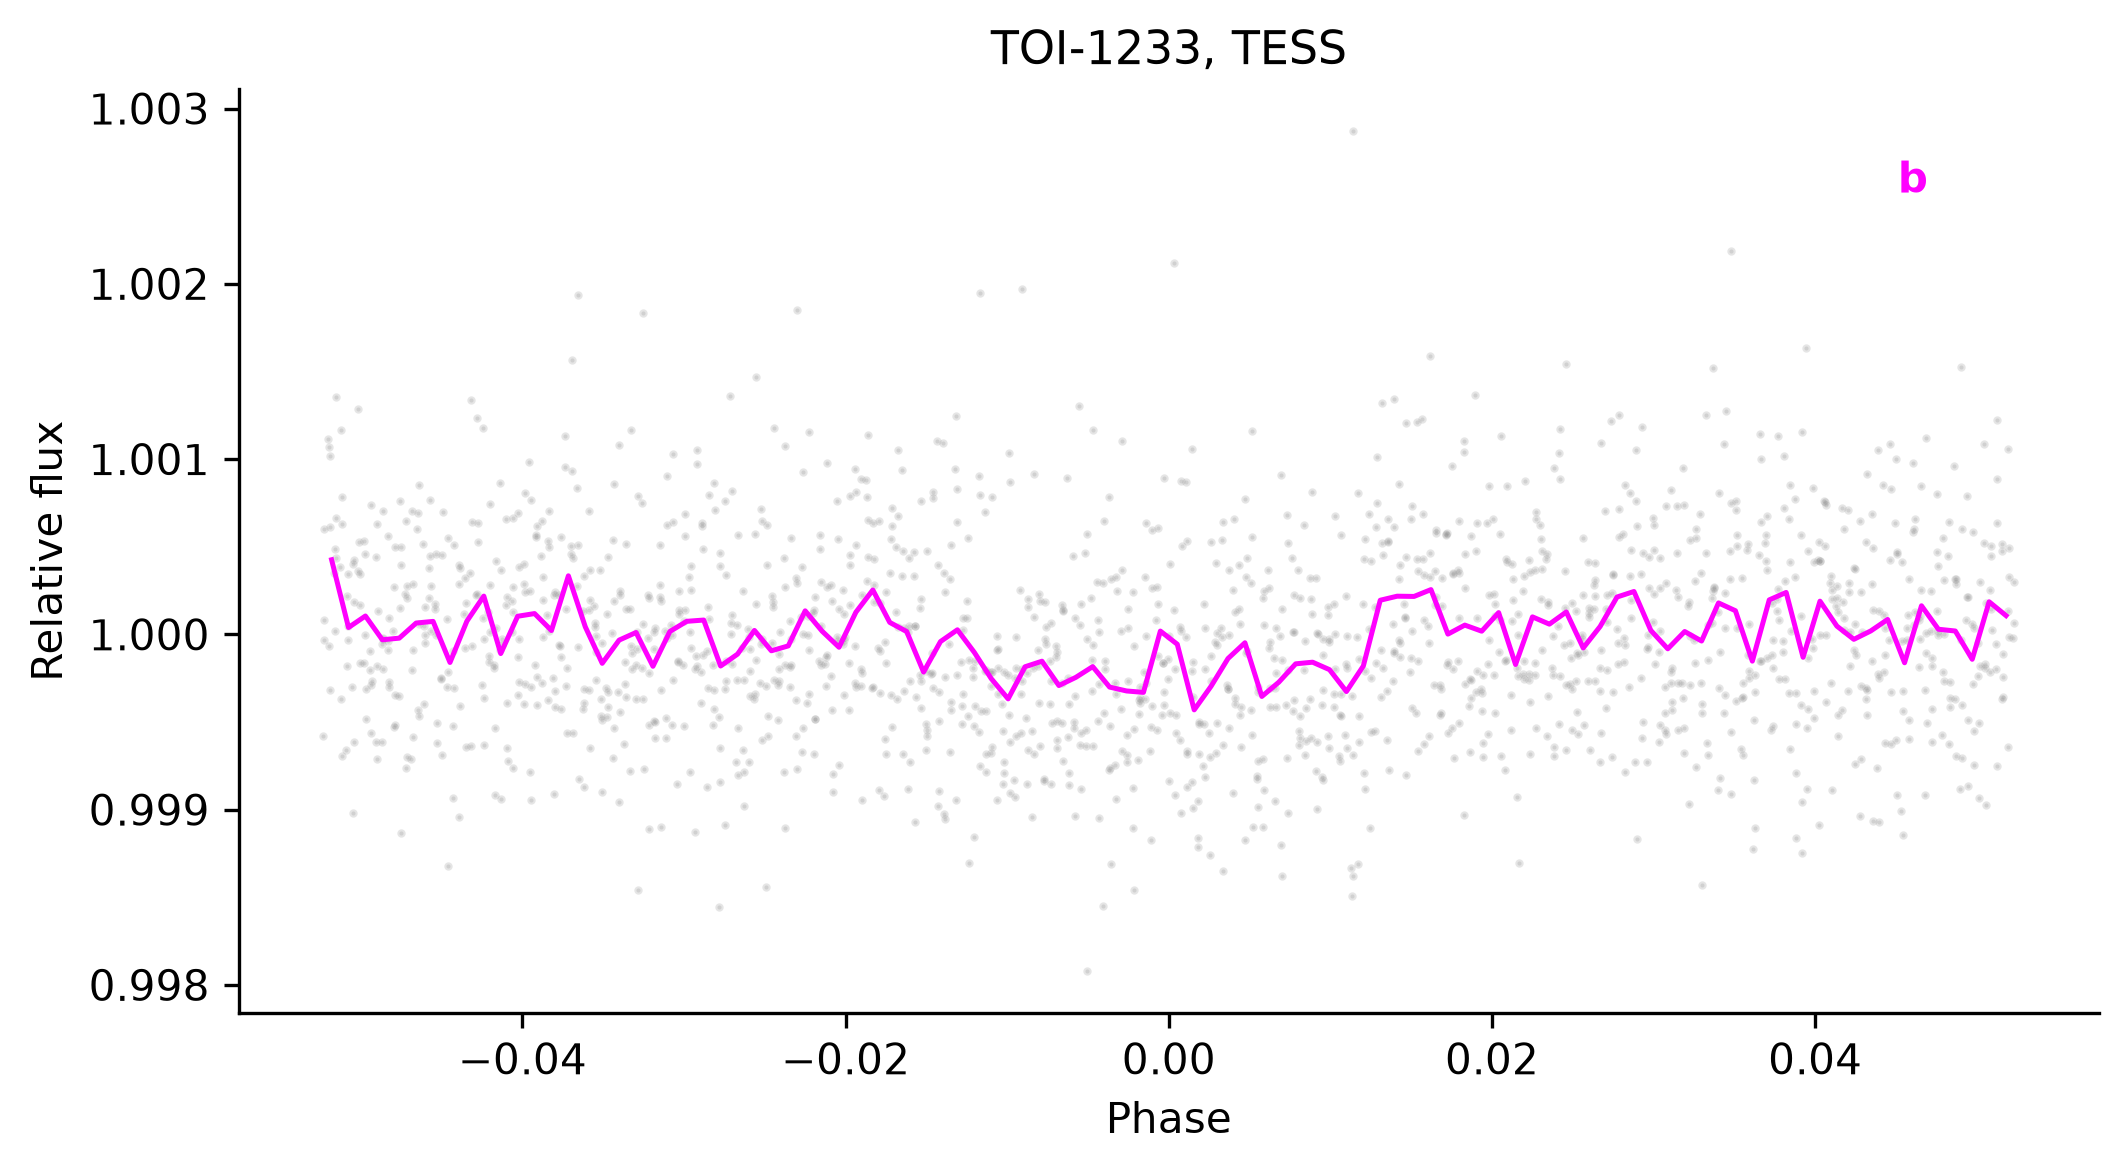

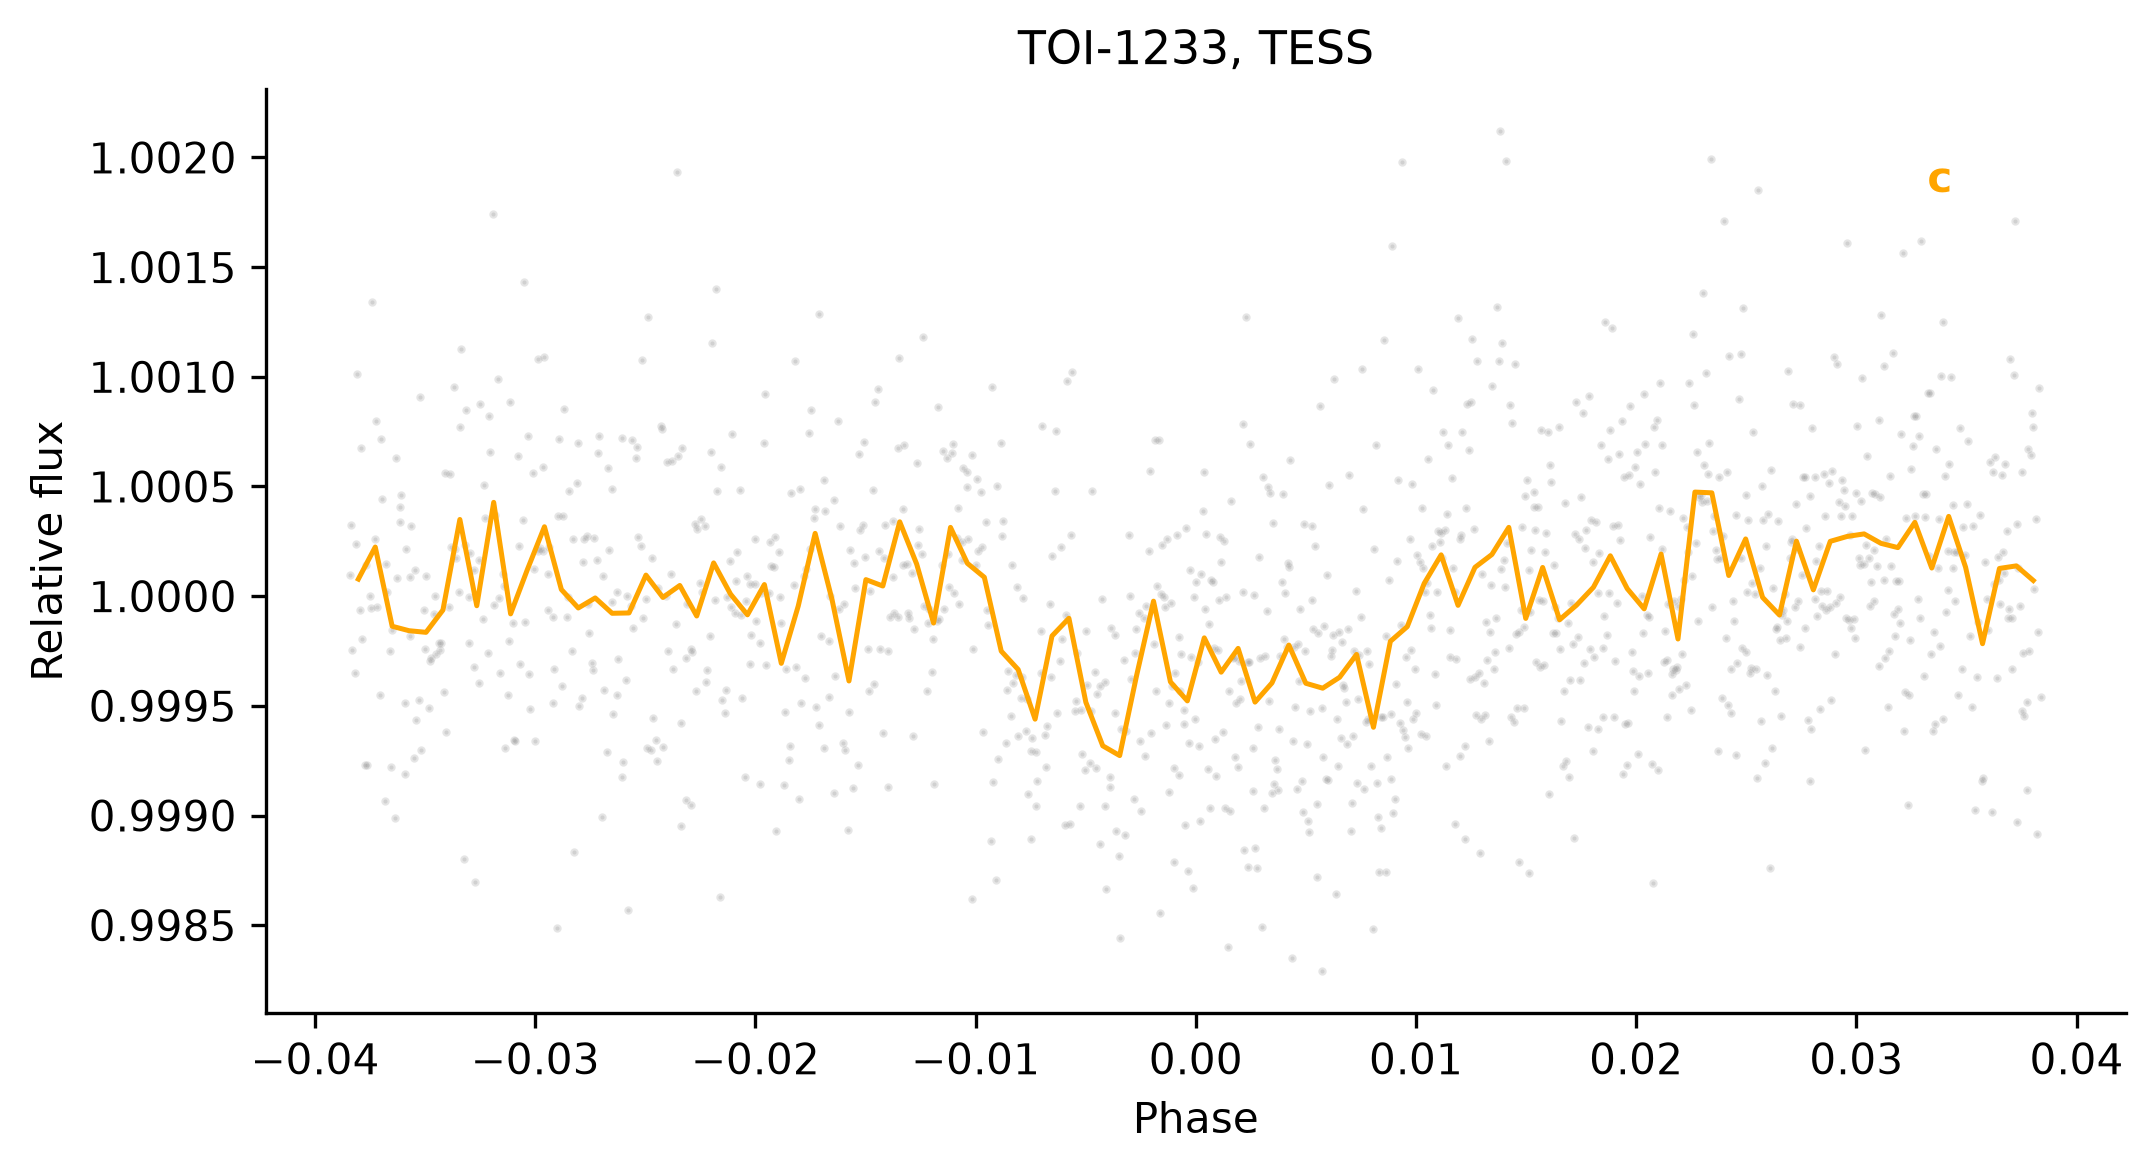

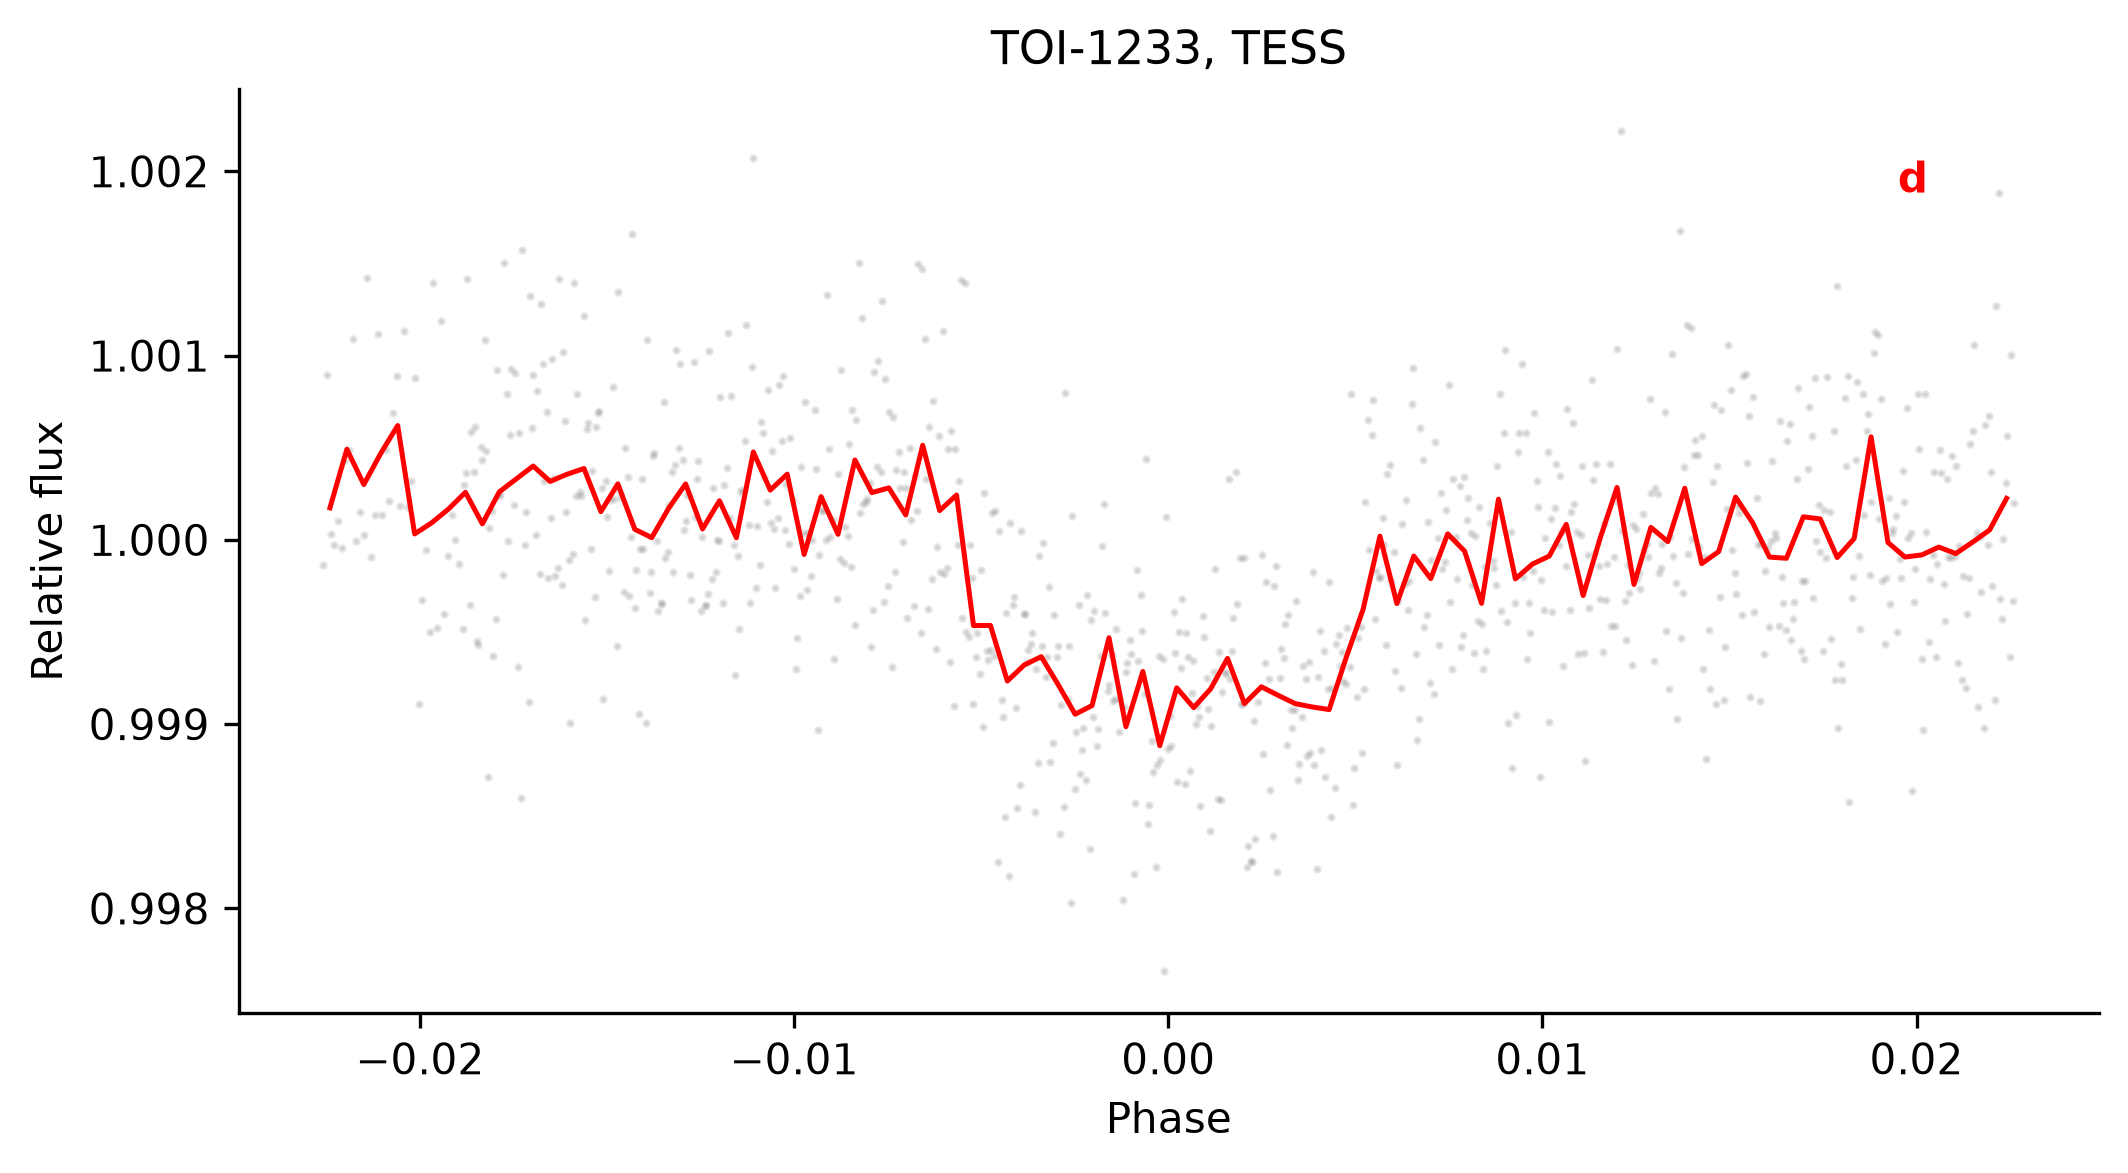

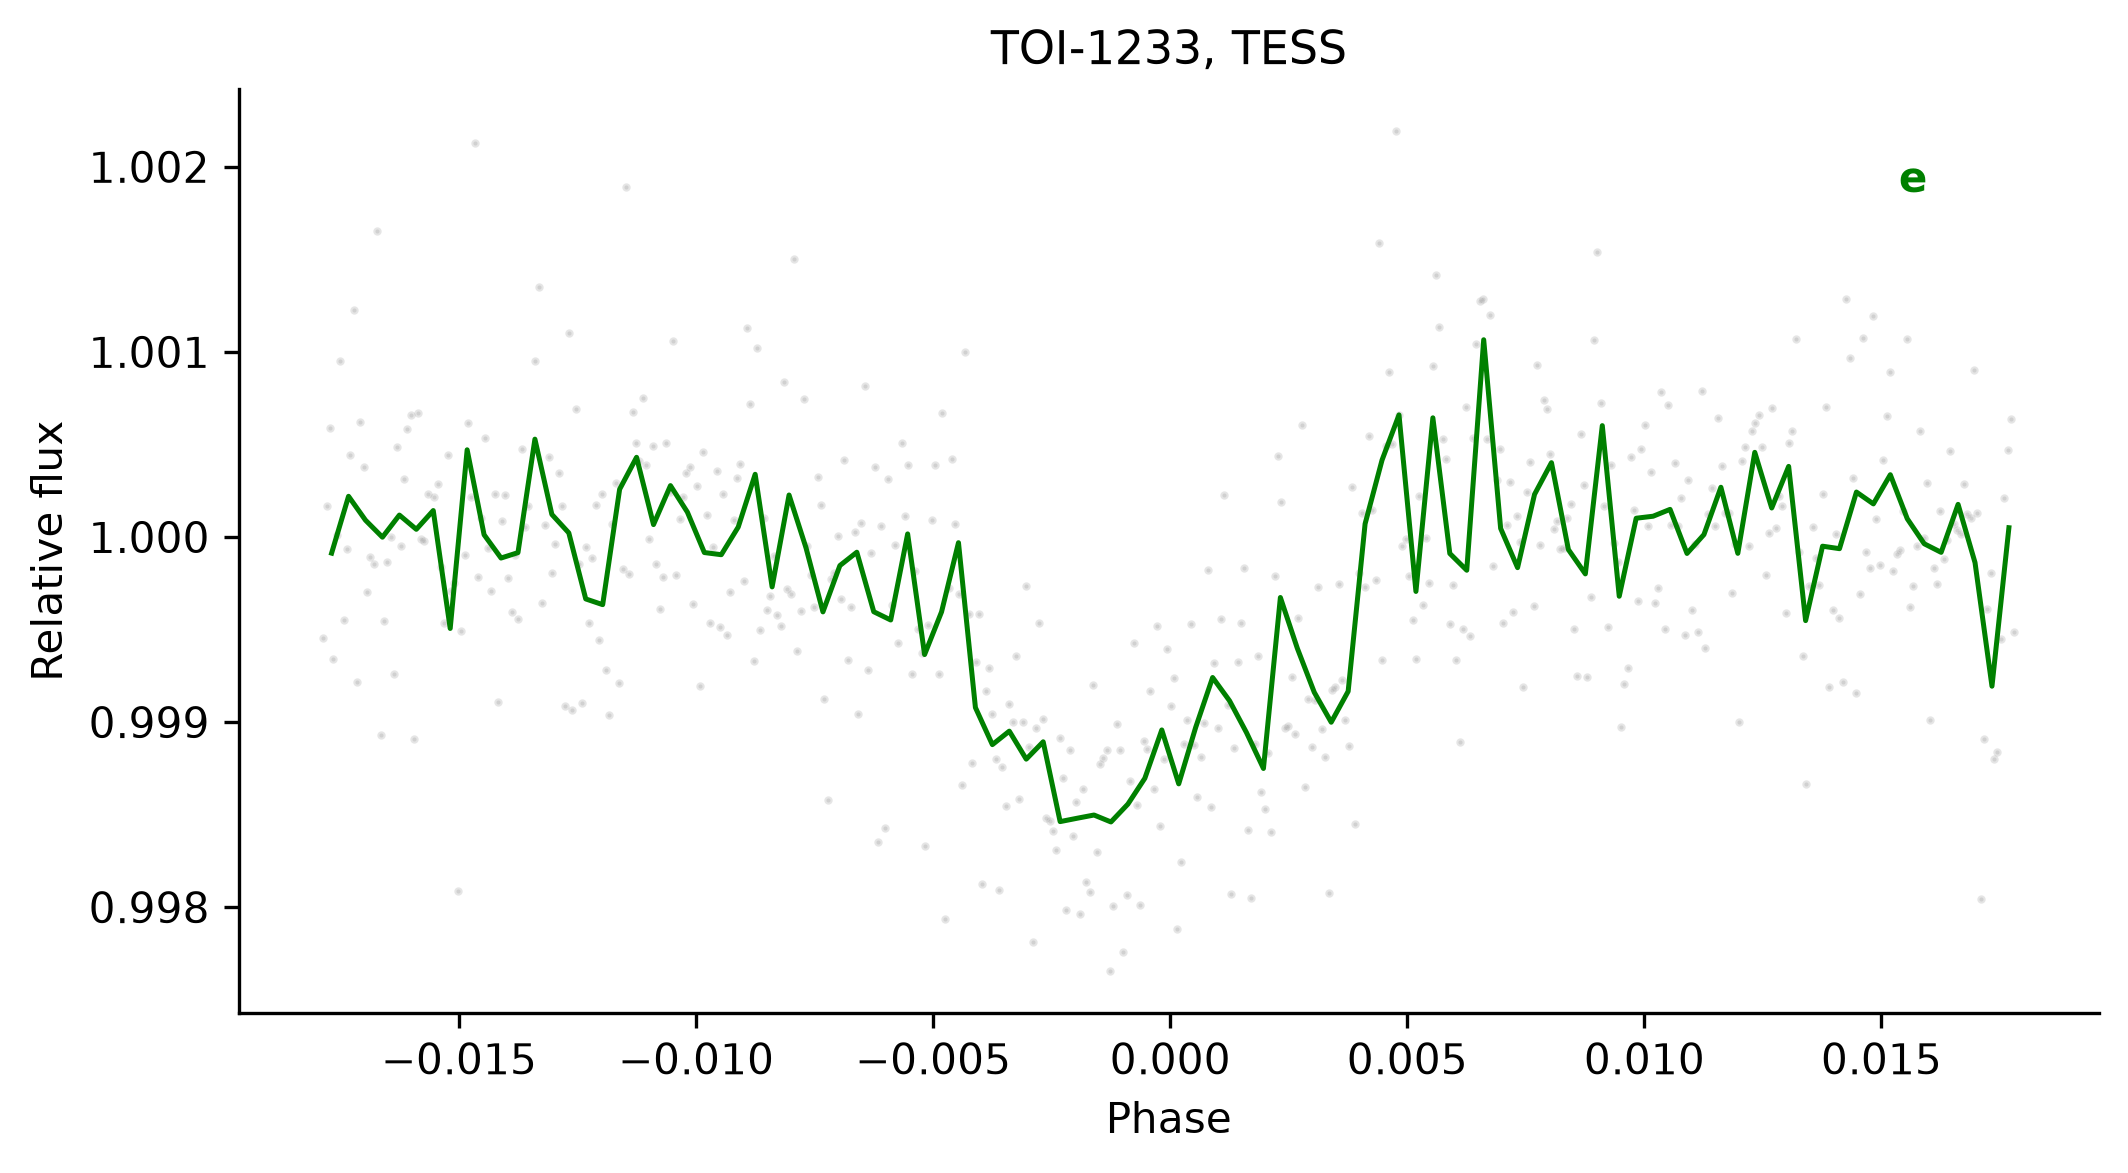

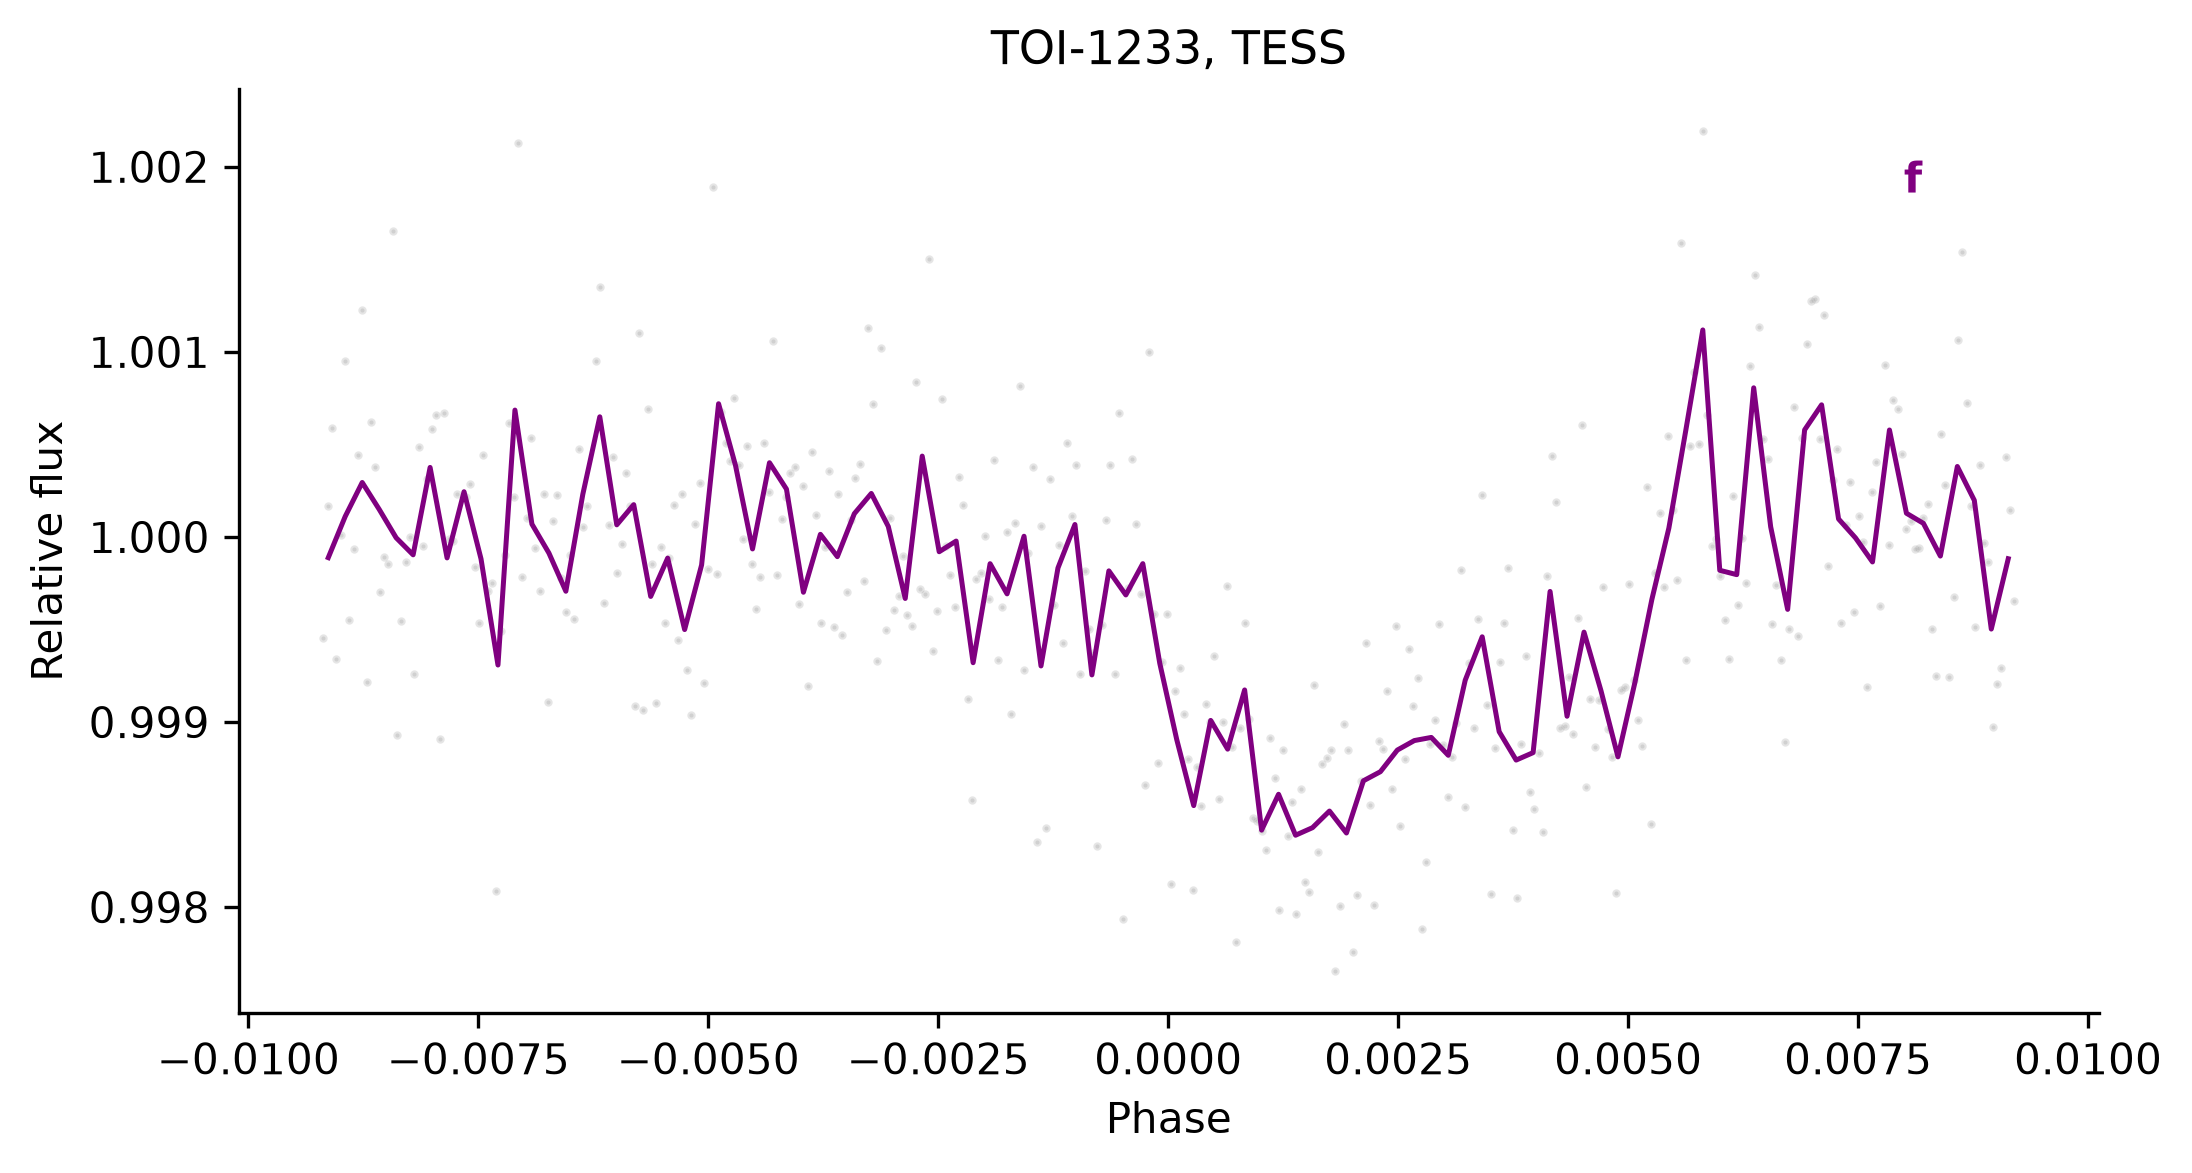

Available summary pages: 6


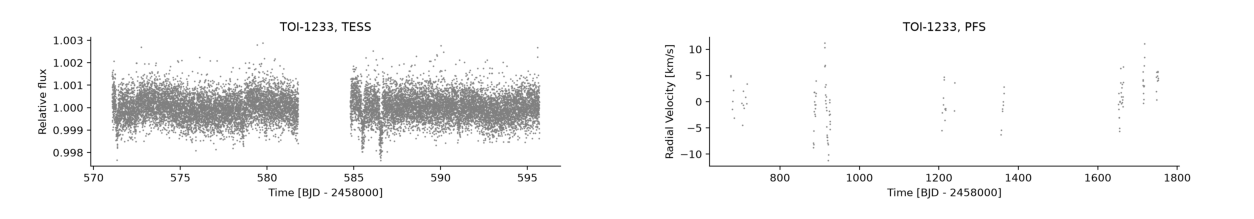

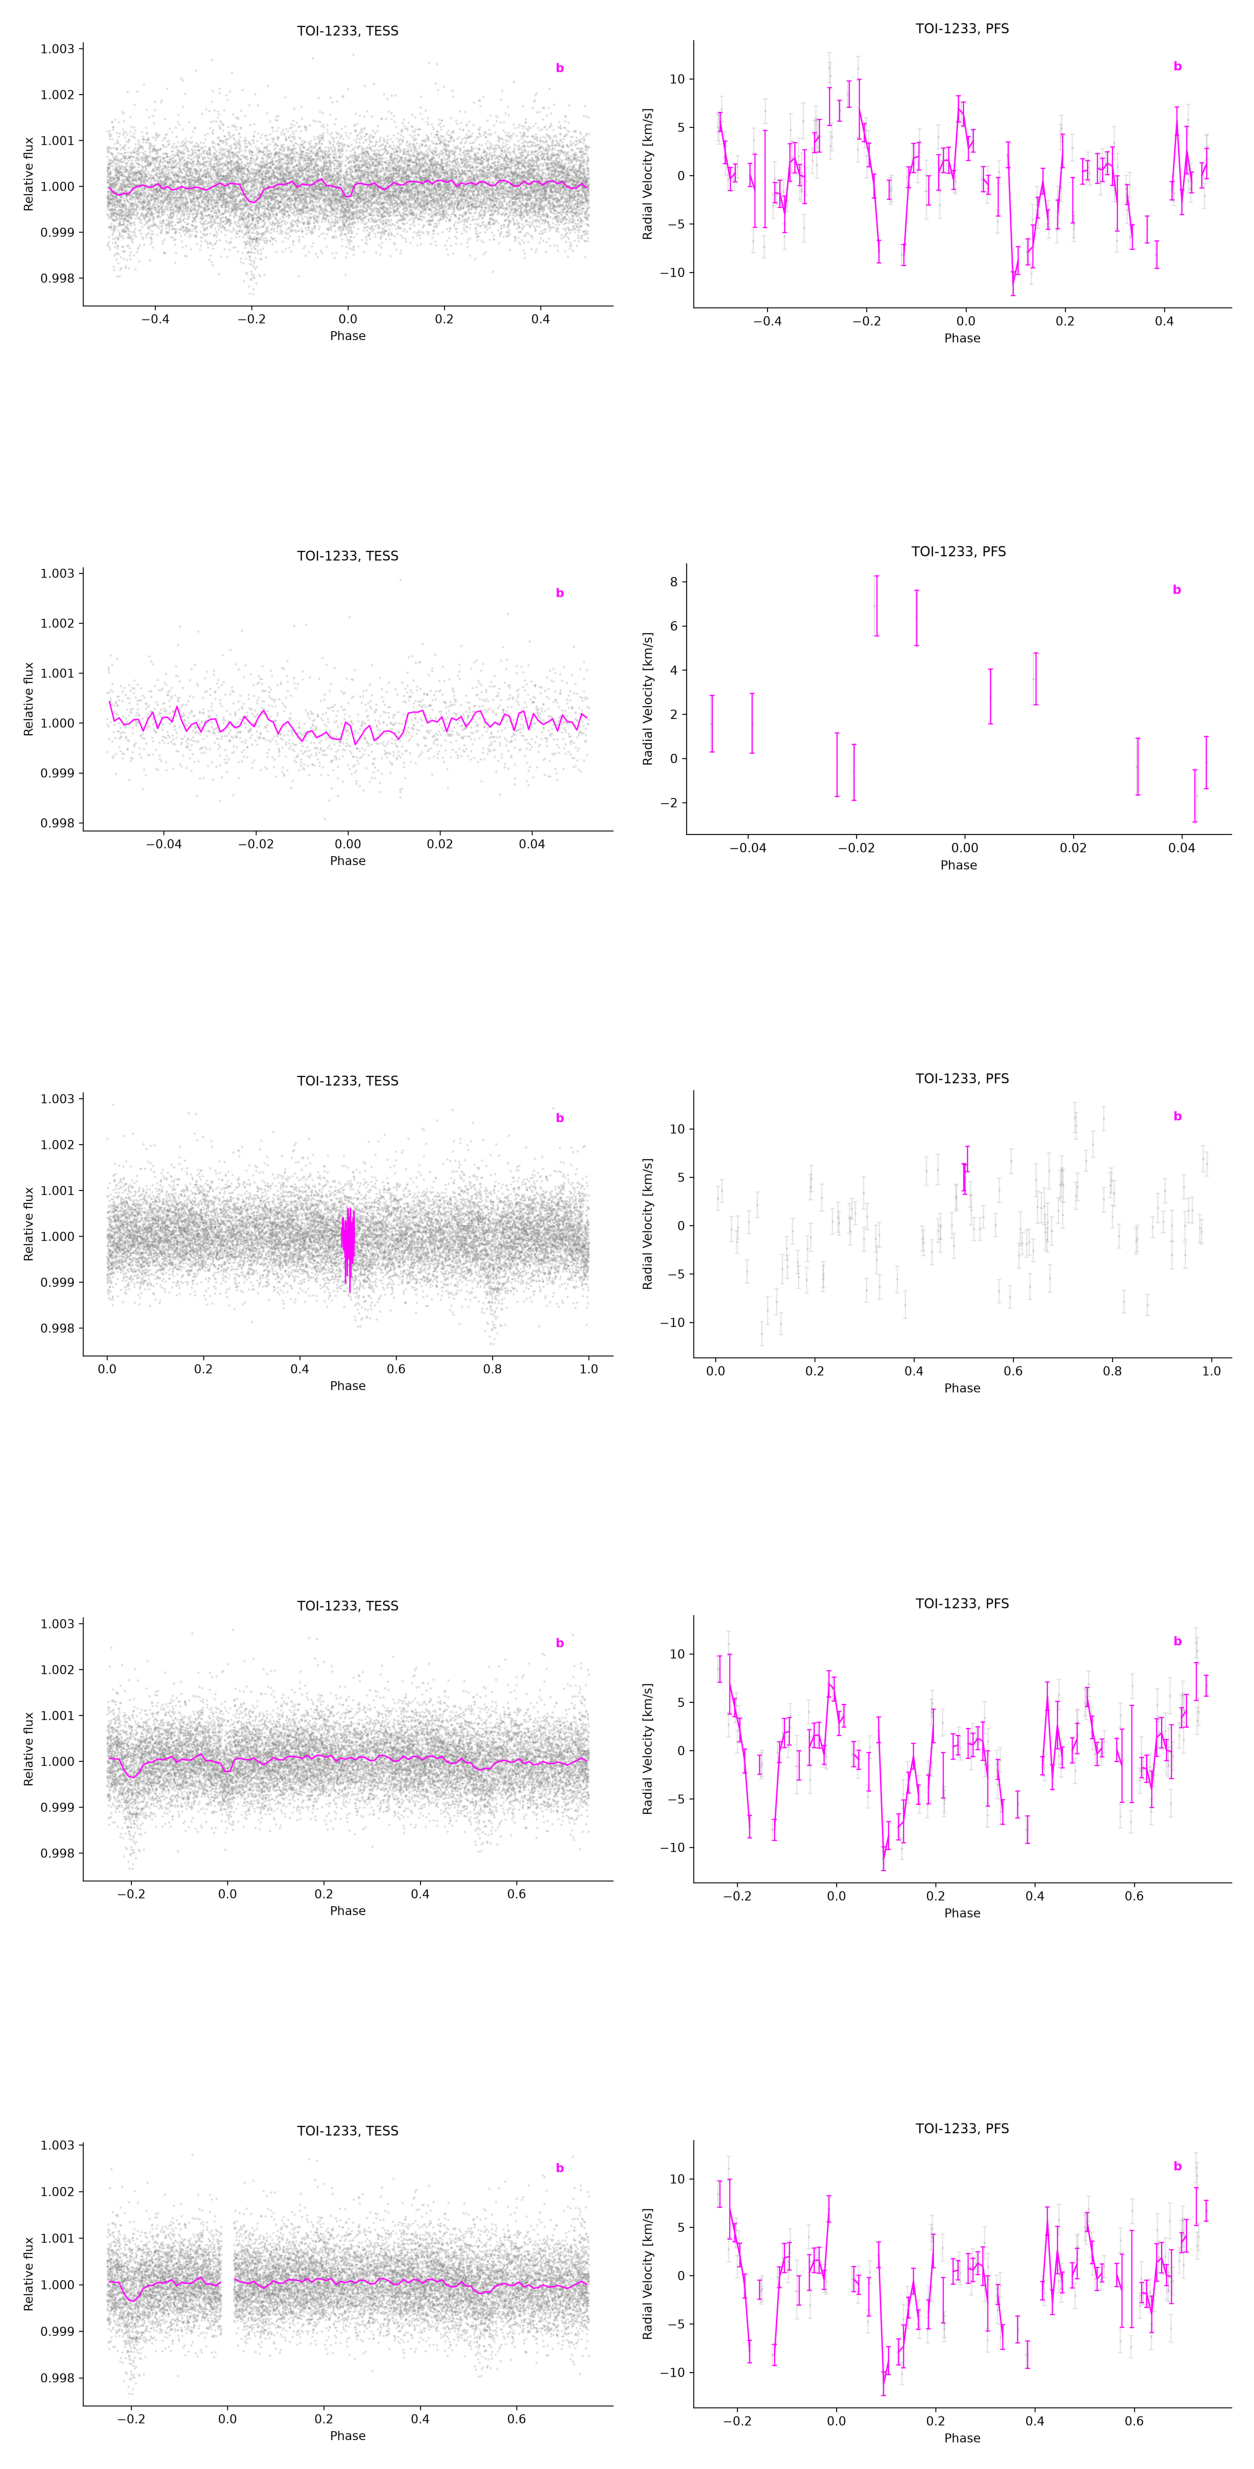

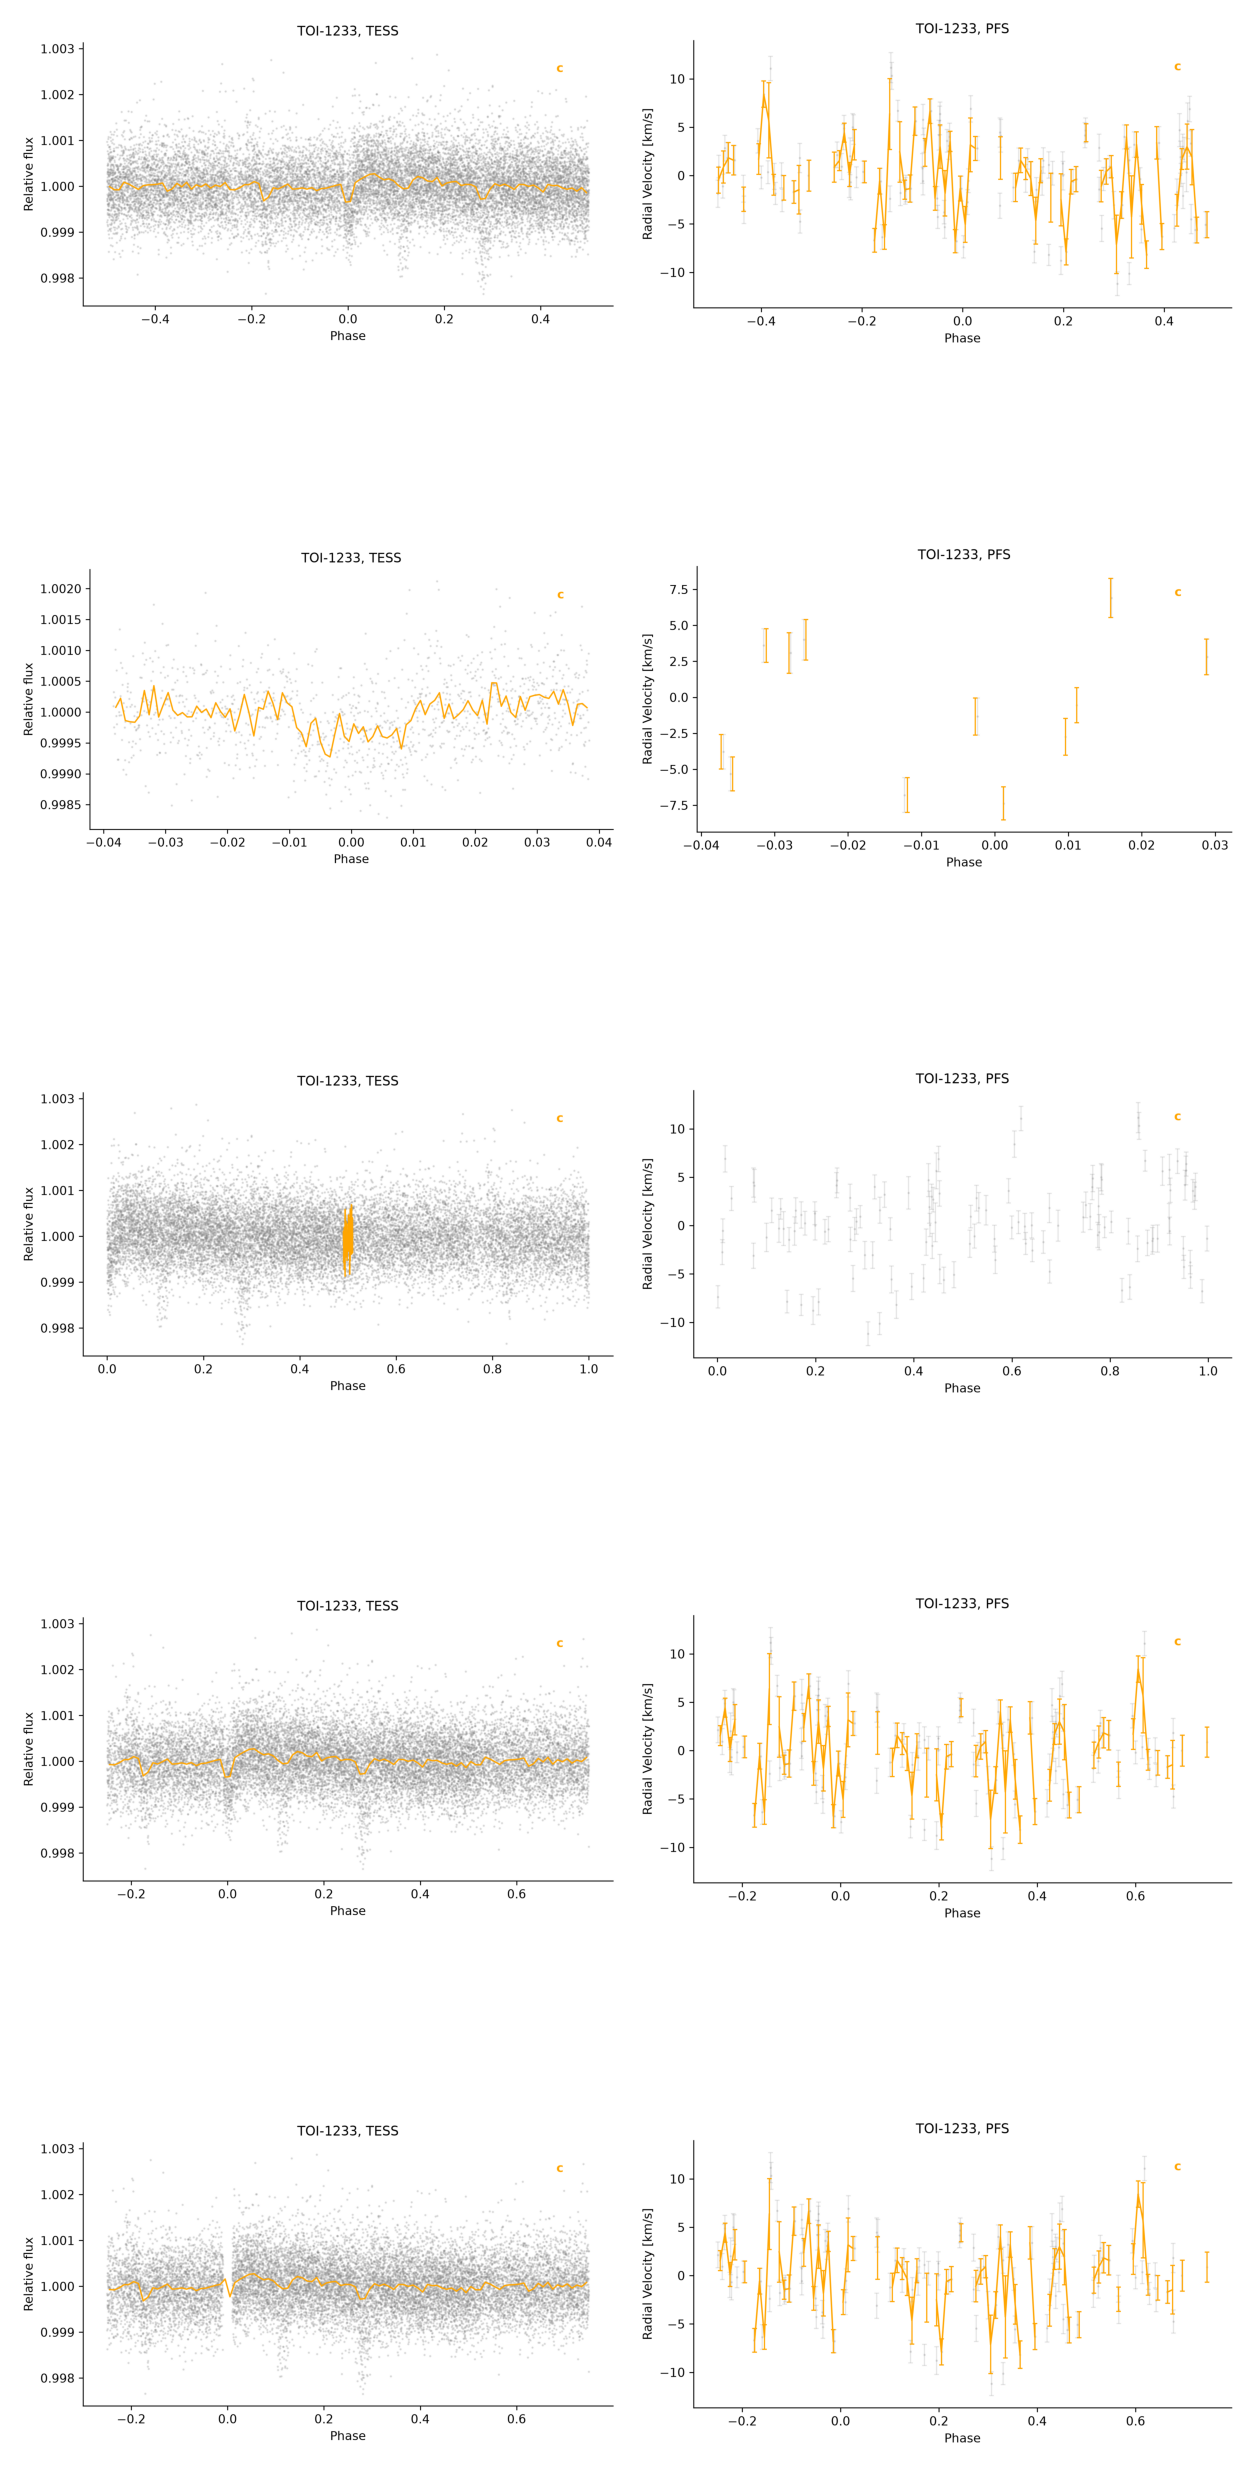

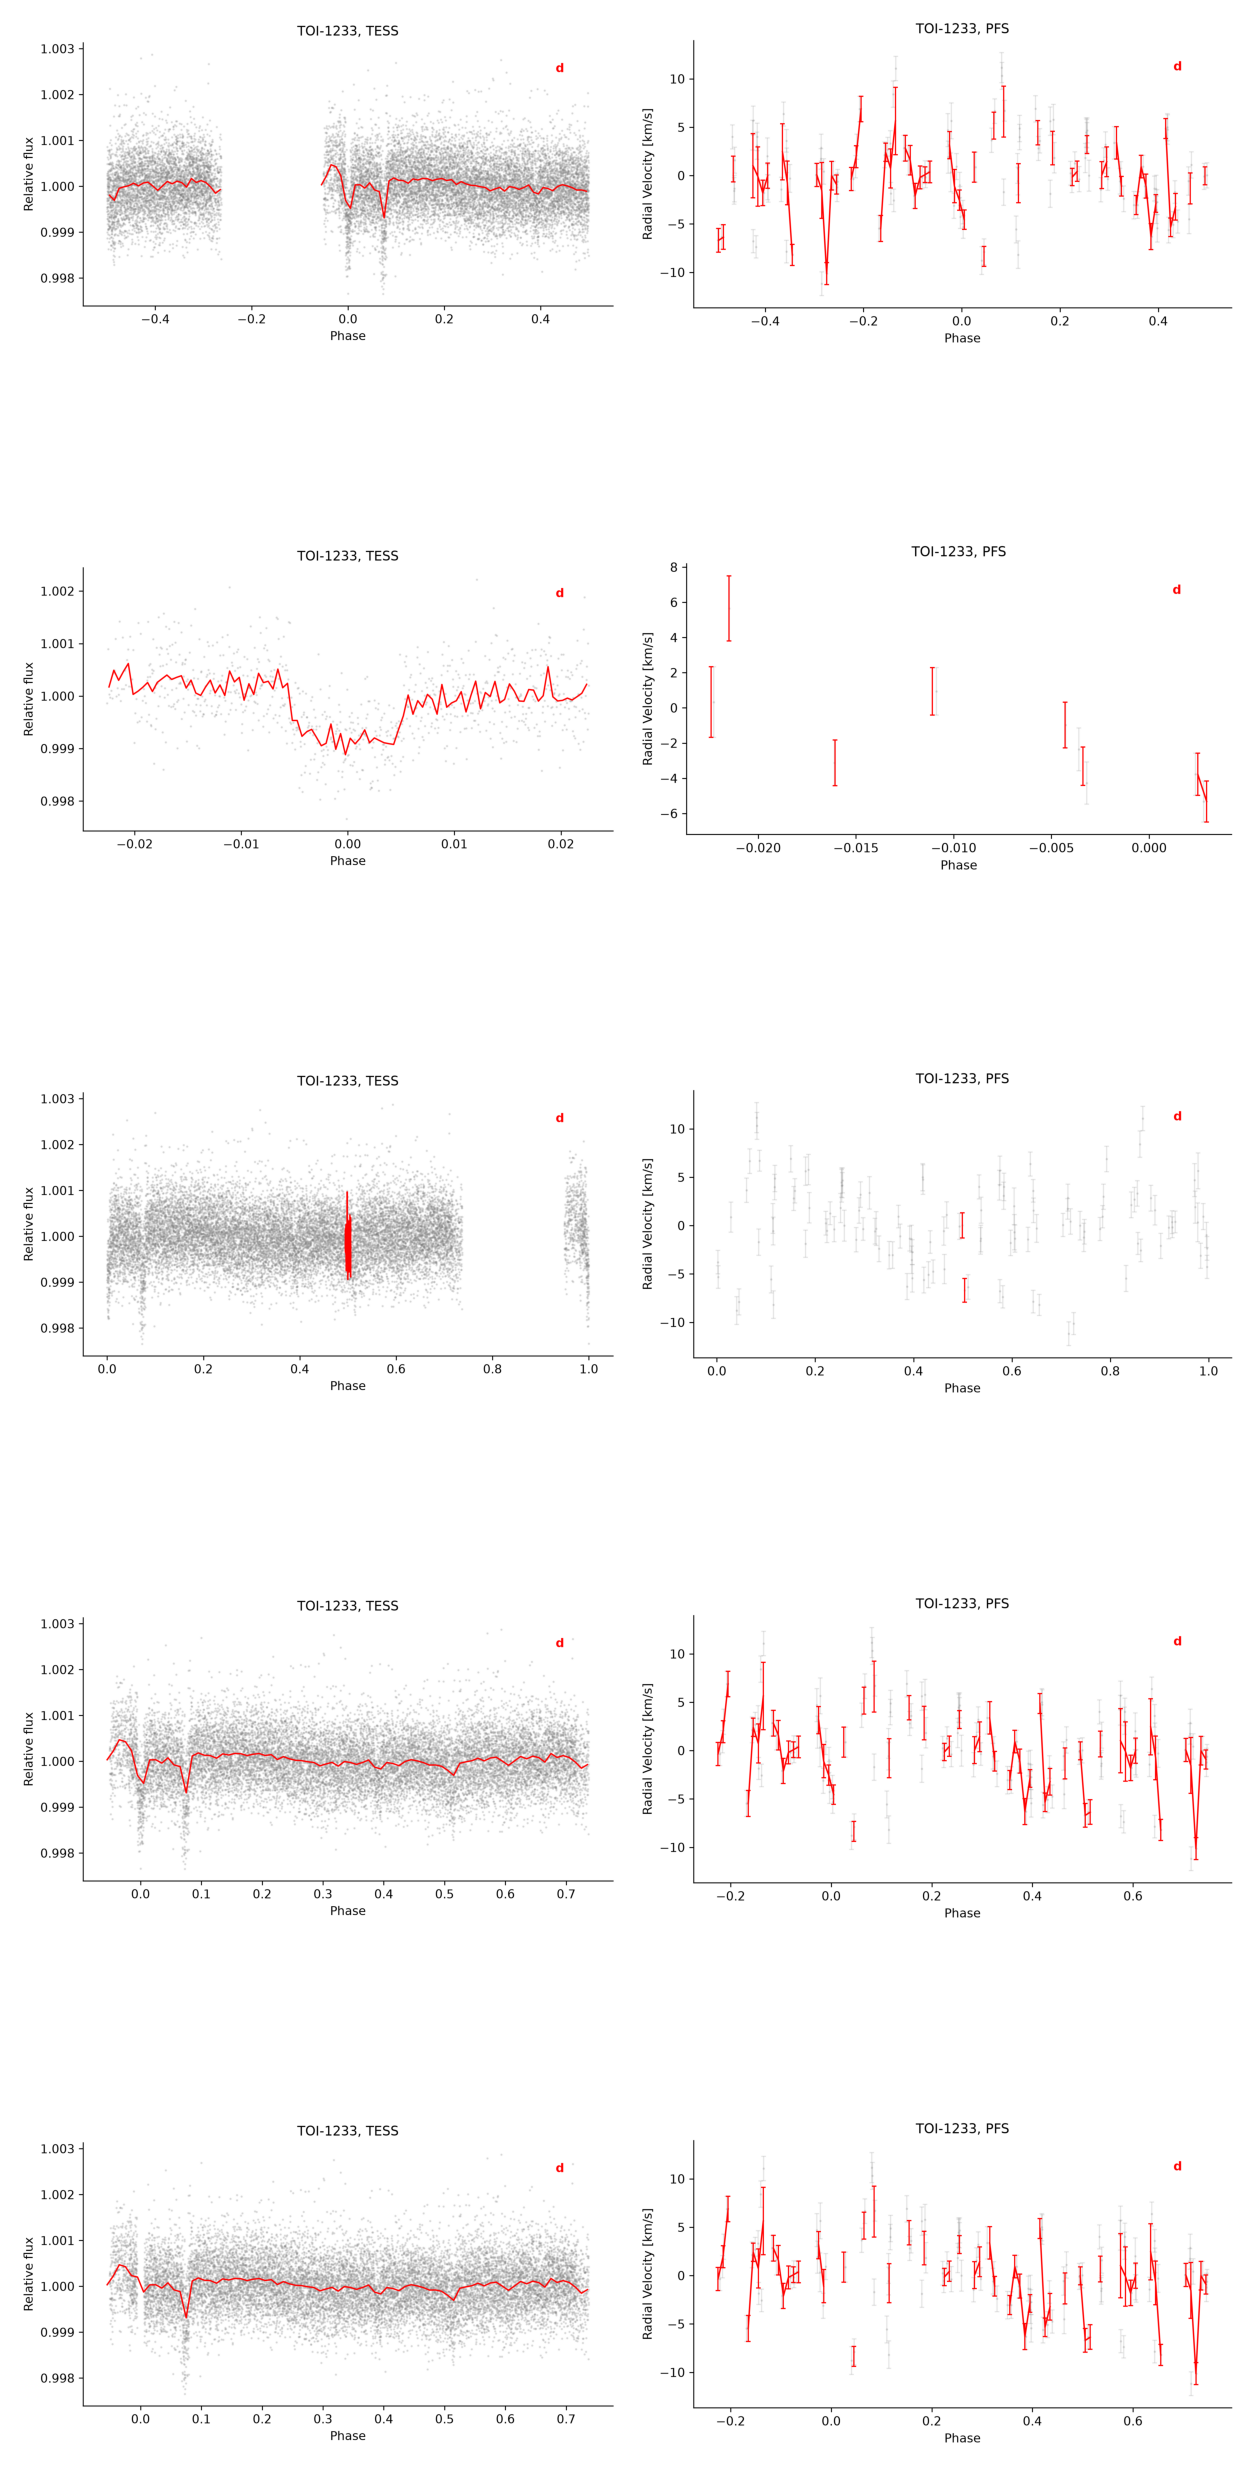

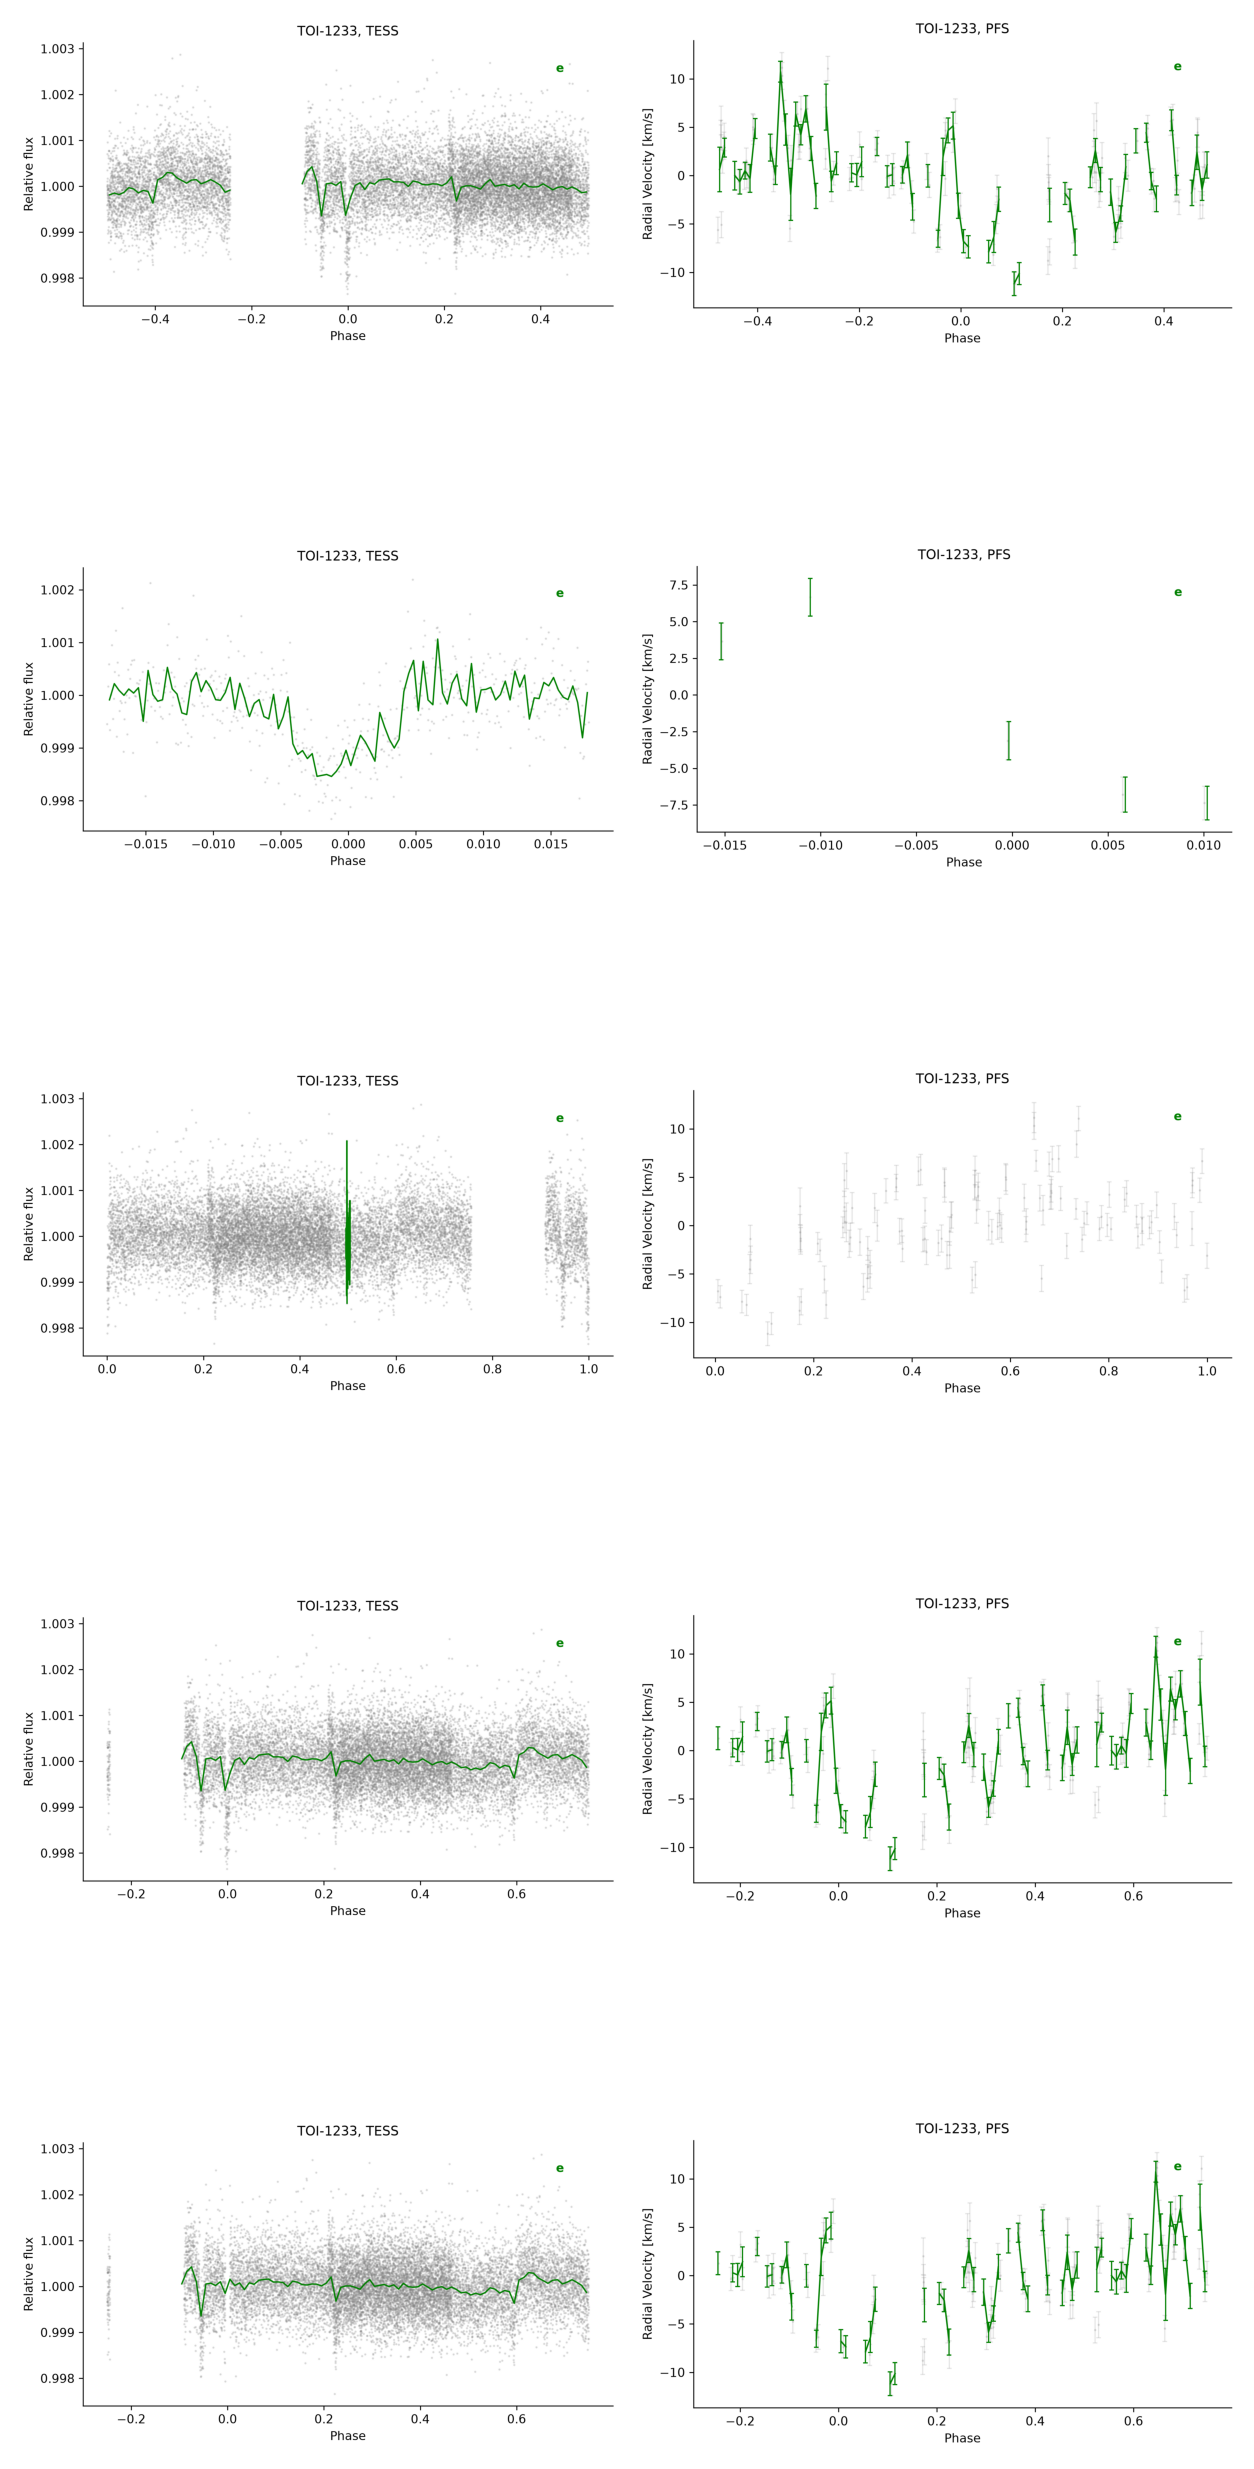

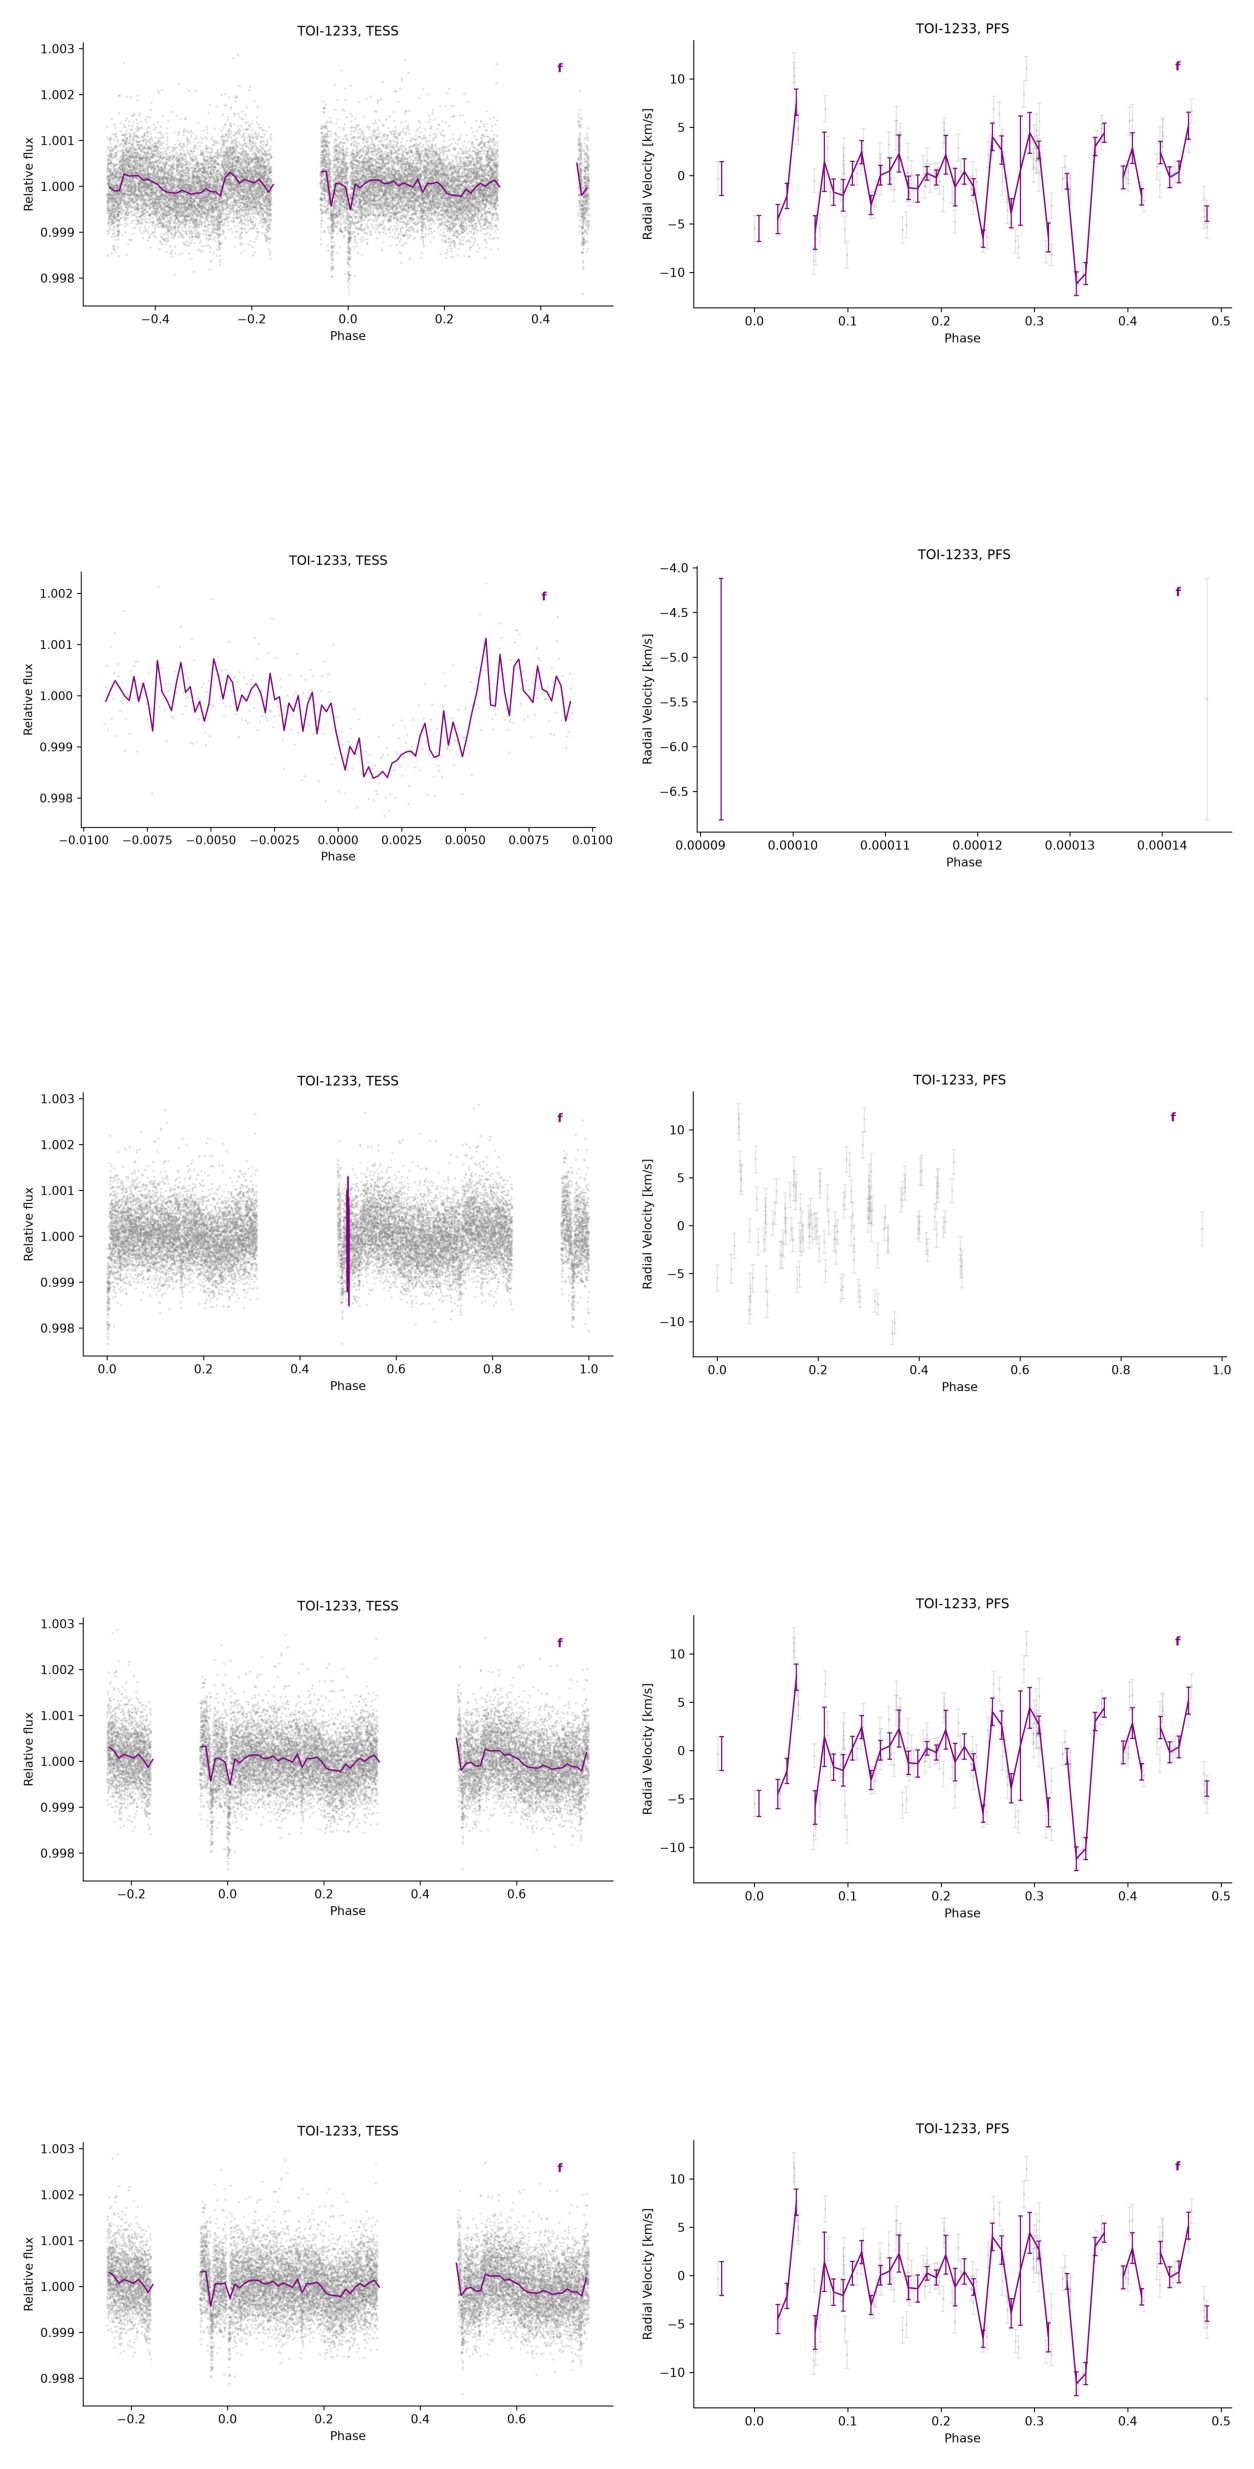

In [3]:
run_analysis = False
if run_analysis:
    result = run_toi1233_observation(typemodl=model, typefileplot="png")
    print(f"Analyzed target: {result['strgtarg']}")

transit_paths = [
    visual_path / f"PhaseCurve_TESS_{letter}_DetrendedPrimaryCenteredZoom_TOI-1233_exar.png"
    for letter in "bcdef"
]
print(f"Phase-folded TESS transits: {len(transit_paths)}")
for figure_path in transit_paths:
    narrate(f"Reading from {figure_path}...")
    display(Image(filename=str(figure_path)))

summary_paths = sorted(visual_path.glob("Summary_Page*.png"))
print(f"Available summary pages: {len(summary_paths)}")
for figure_path in summary_paths:
    narrate(f"Reading from {figure_path}...")
    display(Image(filename=str(figure_path)))